# <center><b>CV Project : Part One</b></center>

In [1]:
# Mounting the personal drive to import the data for the project

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# Switching to appopriate folder to extract files

import os
os.chdir('drive/My Drive/Colab Data/CV_Project_2/Part_One')

## 1. Import the dataset

In [3]:
# For removal of the warnings
import warnings
warnings.filterwarnings("ignore")

# For handling randomness in the output of the models
import numpy as np
import tensorflow as tf
seed = 42
np.random.seed(seed)
tf.random.set_seed(seed)

# Basic Libraries
import numpy as np
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.model_selection import train_test_split
import cv2
from glob import glob
import random
import copy

# DL related libraries
from tensorflow.keras.layers import Conv2D, Activation, BatchNormalization,UpSampling2D, Input, Concatenate, Reshape, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.applications.mobilenet import MobileNet
from tensorflow.keras.applications.mobilenet import preprocess_input
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import binary_crossentropy
from tensorflow.keras.backend import log, epsilon


In [4]:
# Loading the images file

data = np.load('Part 1- Train data - images.npy', allow_pickle=True)

In [5]:
# Checking the shape of the given dataset

data.shape

(409, 2)

So we have 409 images in our training dataset

Let's view some images to check the content

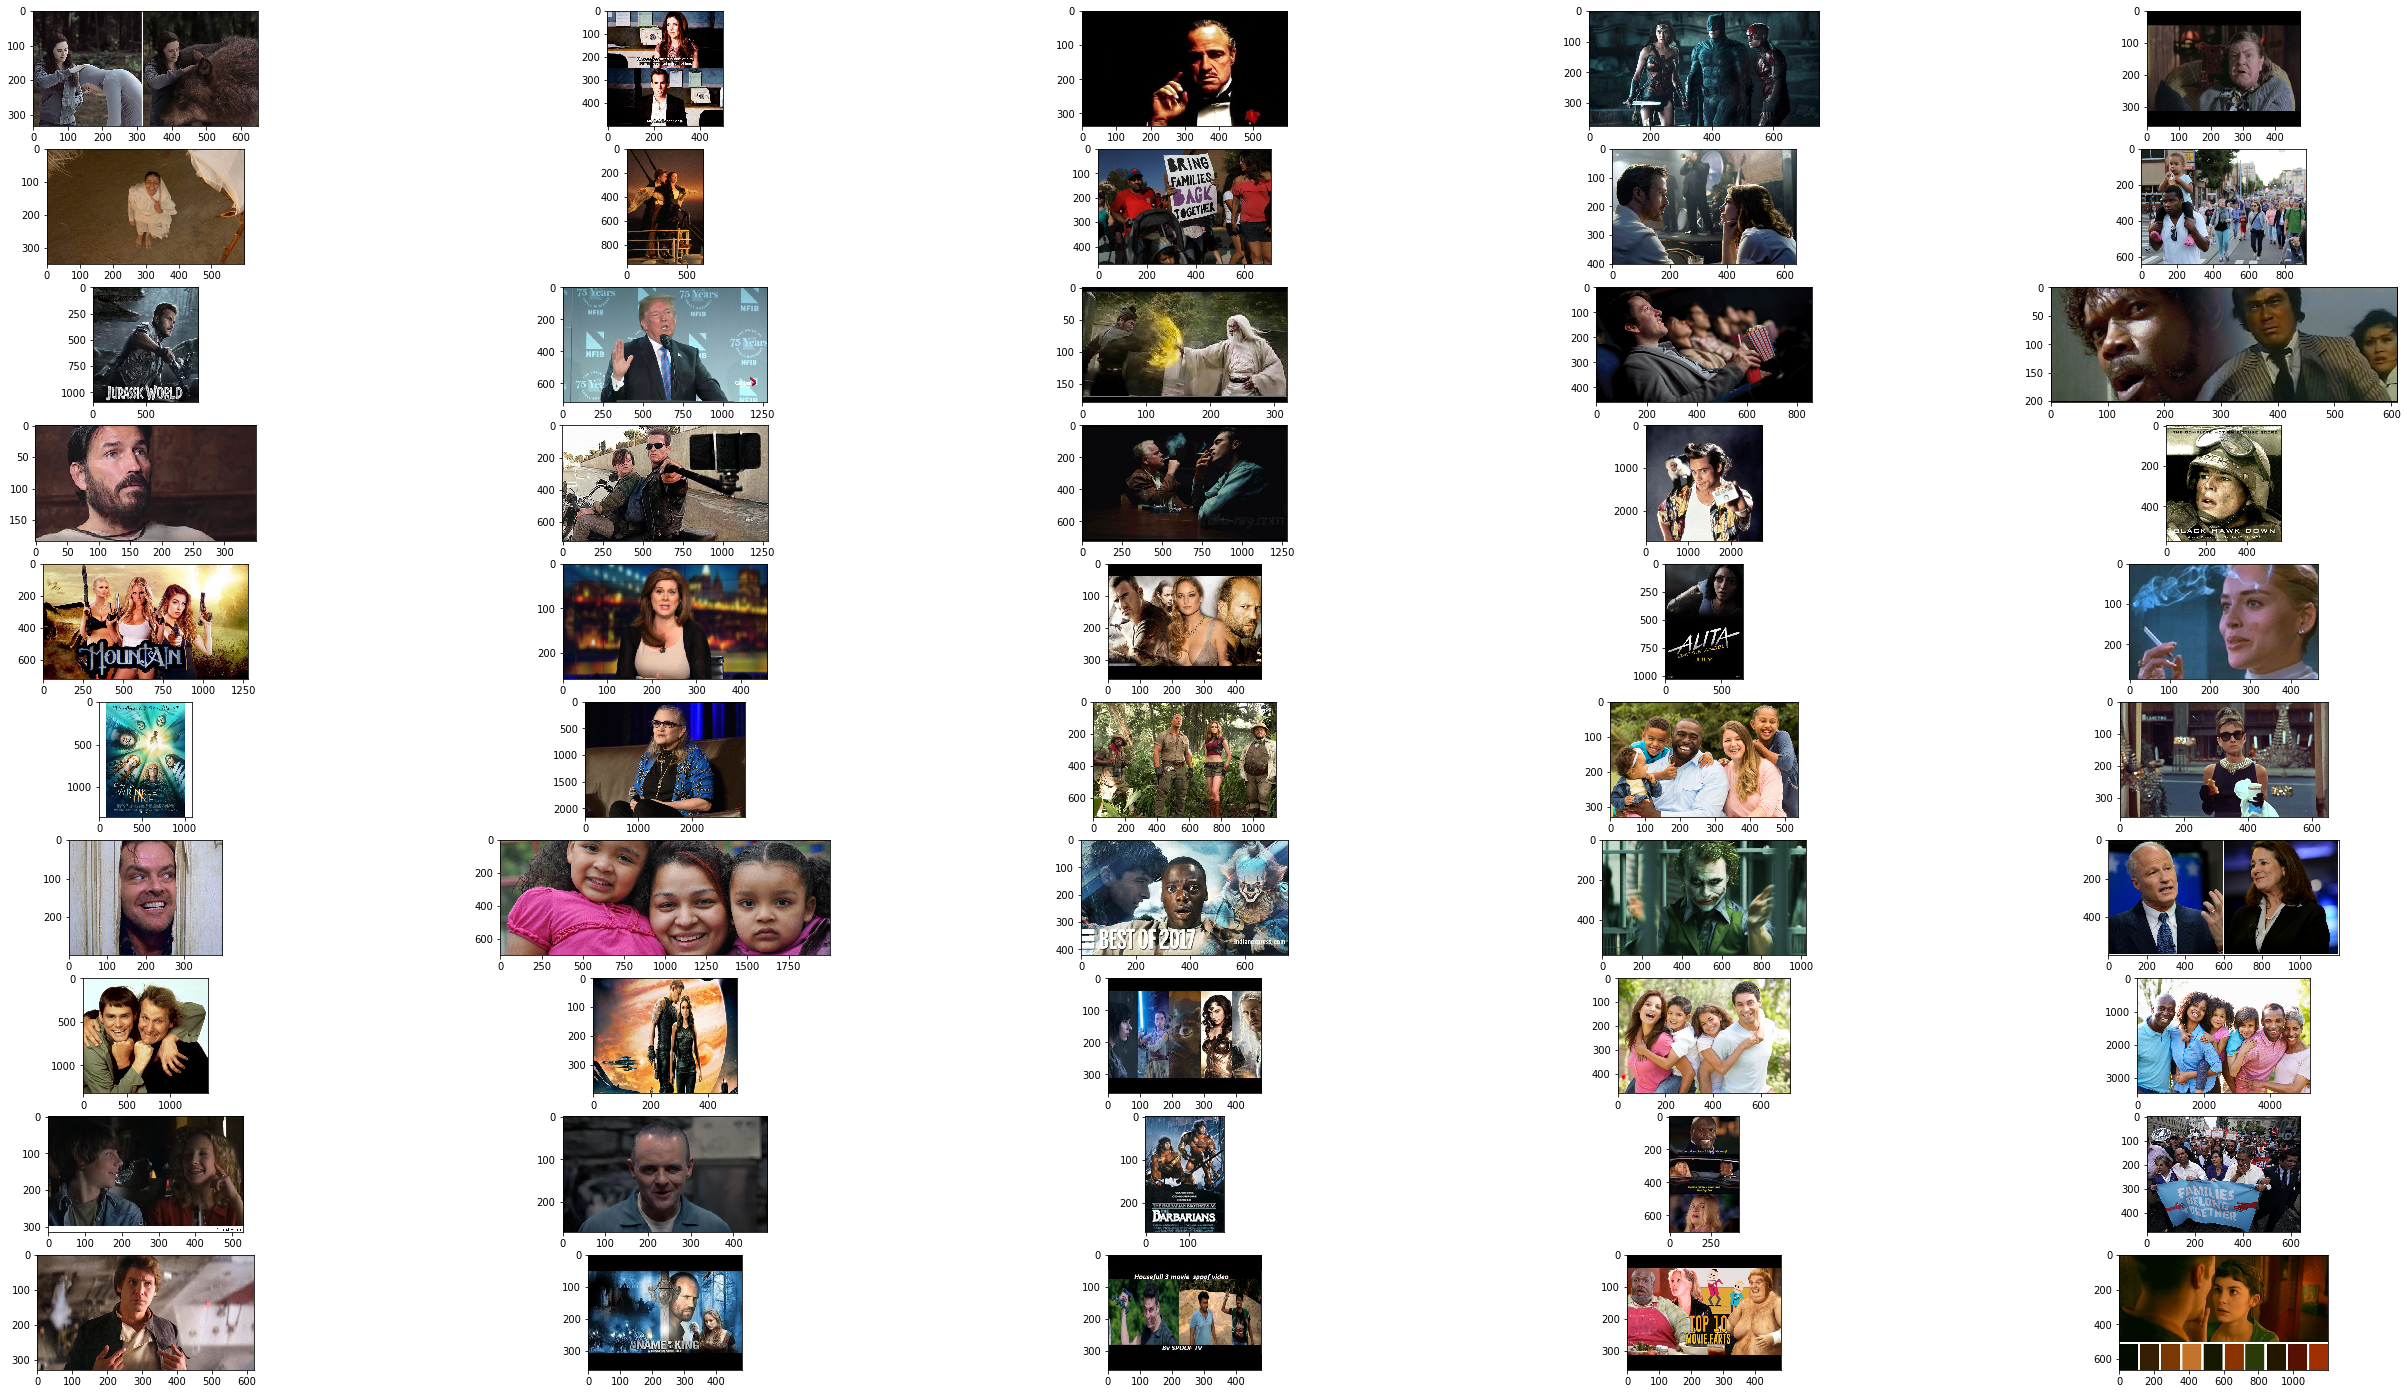

In [6]:
# Displaying images and checking the content of the dataset

fig, ax = plt.subplots(10,5,figsize = (45,25))
row, col, image_sno = 0, 0, 0

for i in range(50):
  ax[row][col].imshow(data[image_sno][0], interpolation='nearest')
  image_sno += 5
  col += 1
  if col > 4:
    row += 1
    col = 0
plt.show()

Let's analyse few images

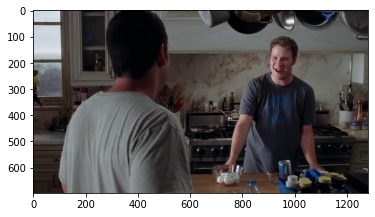

In [7]:
plt.imshow(data[1][0]);

In [8]:
data[1][1]

[{'imageHeight': 697,
  'imageWidth': 1280,
  'label': ['Face'],
  'notes': '',
  'points': [{'x': 0.7053087757313109, 'y': 0.23260437375745527},
   {'x': 0.7692307692307693, 'y': 0.36182902584493043}]}]

We can see that we can see only one face and hence we have single label for this images

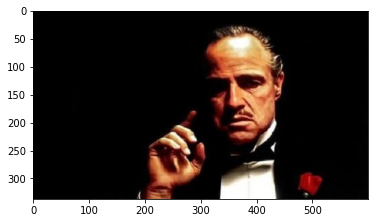

In [9]:
plt.imshow(data[10][0])

In [10]:
data[10][1]

[{'imageHeight': 337,
  'imageWidth': 600,
  'label': ['Face'],
  'notes': '',
  'points': [{'x': 0.48, 'y': 0.10385756676557864},
   {'x': 0.7716666666666666, 'y': 0.6795252225519288}]}]

Since one face can be seen for the image hence, we have one label

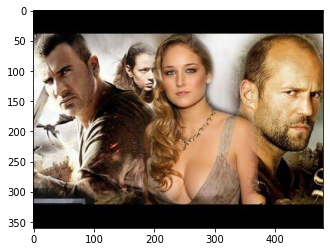

In [11]:
plt.imshow(data[110][0])

In [12]:
data[110][1]

[{'imageHeight': 360,
  'imageWidth': 480,
  'label': ['Face'],
  'notes': '',
  'points': [{'x': 0.425, 'y': 0.13333333333333333},
   {'x': 0.6333333333333333, 'y': 0.4722222222222222}]},
 {'imageHeight': 360,
  'imageWidth': 480,
  'label': ['Face'],
  'notes': '',
  'points': [{'x': 0.0125, 'y': 0.1388888888888889},
   {'x': 0.25, 'y': 0.5166666666666667}]},
 {'imageHeight': 360,
  'imageWidth': 480,
  'label': ['Face'],
  'notes': '',
  'points': [{'x': 0.3125, 'y': 0.14722222222222223},
   {'x': 0.4375, 'y': 0.4083333333333333}]},
 {'imageHeight': 360,
  'imageWidth': 480,
  'label': ['Face'],
  'notes': '',
  'points': [{'x': 0.75, 'y': 0.13333333333333333},
   {'x': 1, 'y': 0.5805555555555556}]}]

Since four faces can be seen for the image hence, we have four labels

- Now from the above shown images we can see that we have appropriate count of labels.
- Also, we could see the images are of different resolutions

##2. Create features (images) and labels (mask) using that data

In [13]:
# Setting up the dimensions for generalizing the images

IMAGE_SIZE = 224
IMAGE_HEIGHT = 224
IMAGE_WIDTH = 224

In [14]:
# Creating features and labels

masks = np.zeros((int(data.shape[0]), IMAGE_HEIGHT, IMAGE_WIDTH))
X = np.zeros((int(data.shape[0]), IMAGE_HEIGHT, IMAGE_WIDTH, 3))
for index in range(data.shape[0]):
    img = data[index][0]
    img = cv2.resize(img, dsize = (IMAGE_HEIGHT, IMAGE_WIDTH), interpolation = cv2.INTER_CUBIC)
    try:
      img = img[:, :, :3]
    except:
      continue
    X[index] = preprocess_input(np.array(img, dtype = np.float32))
    for i in data[index][1]:
        x1 = int(i['points'][0]['x'] * IMAGE_WIDTH)
        x2 = int(i['points'][1]['x'] * IMAGE_WIDTH)
        y1 = int(i['points'][0]['y'] * IMAGE_HEIGHT)
        y2 = int(i['points'][1]['y'] * IMAGE_HEIGHT)
        masks[index][y1:y2, x1:x2] = 1

In [15]:
print('Shape of transformed images: ', X.shape)

Shape of transformed images:  (409, 224, 224, 3)


In [16]:
print('Shape of masks: ', masks.shape)

Shape of masks:  (409, 224, 224)


Let's now check out the previous images and their masks

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


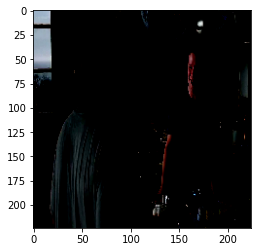

In [17]:
plt.imshow(X[1])

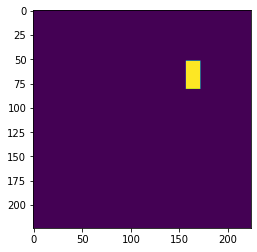

In [18]:
plt.imshow(masks[1])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


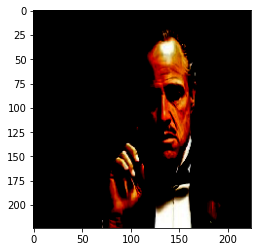

In [19]:
plt.imshow(X[10])

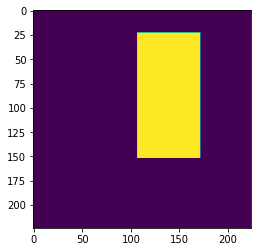

In [20]:
plt.imshow(masks[10])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


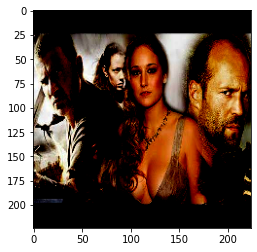

In [21]:
plt.imshow(X[110])

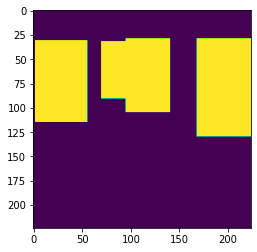

In [22]:
plt.imshow(masks[110])

We can see that images have been transformed and masks looks quite appropriate for each images shown

In [23]:
# Splitting the training and validation data

X_train, X_test, y_train, y_test = train_test_split(X, masks, test_size=0.25)
X_valid, X_test, y_valid, y_test = train_test_split(X_test, y_test, test_size=0.25)

In [24]:
print(f'Shape of X_train is "{X_train.shape}"')

Shape of X_train is "(306, 224, 224, 3)"


In [25]:
print(f'Shape of X_train is "{y_train.shape}"')

Shape of X_train is "(306, 224, 224)"


In [26]:
print(f'Shape of X_train is "{X_valid.shape}"')

Shape of X_train is "(77, 224, 224, 3)"


In [27]:
print(f'Shape of X_train is "{y_valid.shape}"')

Shape of X_train is "(77, 224, 224)"


In [28]:
print(f'Shape of X_train is "{X_test.shape}"')

Shape of X_train is "(26, 224, 224, 3)"


In [29]:
print(f'Shape of X_train is "{y_test.shape}"')

Shape of X_train is "(26, 224, 224)"


## 3. Mask detection model:

### <center><b>Design a face mask detection model</b></center>

In [30]:
# Function to create the model

def my_model(trainable = True):

    """ Function to create the model for face mask detection"""

    IMG_SHAPE = (IMAGE_HEIGHT, IMAGE_WIDTH, 3)

    model = MobileNet(input_shape = IMG_SHAPE, alpha = 1, include_top = False, weights = 'imagenet')
    
    for layer in model.layers:
        layer.trainable = trainable

    block0 = model.get_layer('conv_pw_1_relu').output
    block1 = model.get_layer('conv_pw_3_relu').output
    block2 = model.get_layer('conv_pw_5_relu').output
    block3 = model.get_layer('conv_pw_11_relu').output
    block4 = model.get_layer('conv_pw_13_relu').output

    x = Concatenate()([UpSampling2D()(block4), block3])
    x = Concatenate()([UpSampling2D()(x), block2])
    x = Concatenate()([UpSampling2D()(x), block1])
    x = Concatenate()([UpSampling2D()(x), block0])
    x = UpSampling2D()(x)
    x = Conv2D(1, kernel_size = 1, activation = "sigmoid")(x)

    x = Reshape((IMAGE_HEIGHT, IMAGE_HEIGHT))(x)

    return Model(inputs = model.input, outputs = x)

In [31]:
# Creating the model

model = my_model()

In [32]:
# Displaying the summary

model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv1 (Conv2D)                 (None, 112, 112, 32  864         ['input_1[0][0]']                
                                )                                                                 
                                                                                                  
 conv1_bn (BatchNormalization)  (None, 112, 112, 32  128         ['conv1[0][0]']                  
                                )                                                             

### <center><b>Design your own Dice Coefficient and Loss function</b></center>

In [33]:
# Function for dice coefficient

def dice_coefficient(y_true, y_pred):
    numerator = 2 * tf.reduce_sum(y_true * y_pred)
    denominator = tf.reduce_sum(y_true + y_pred)

    return numerator / (denominator + tf.keras.backend.epsilon())

In [34]:
# Function for loss

def loss(y_true, y_pred):
    return binary_crossentropy(y_true, y_pred) - log(dice_coefficient(y_true, y_pred) + tf.keras.backend.epsilon())

### <center><b>Train, tune and test the model</b></center>

In [35]:
# Setting up values for training and tuning

epochs = 5
batch = 8
lr = 2e-4
optimizer = Adam(lr=lr, beta_1=0.9, beta_2=0.999, epsilon=None, decay=0.0, amsgrad=False)

In [36]:
# Compiling the model

model.compile(loss=loss, optimizer=optimizer, metrics=dice_coefficient)

In [37]:
# Adjusting the callbacks

checkpoint = ModelCheckpoint("model-{loss:.2f}.h5", monitor="loss", verbose=1, save_best_only=True, save_weights_only=True, mode="min", save_freq=1)

stop = EarlyStopping(monitor="loss", patience=5, mode="min")

reduce_lr = ReduceLROnPlateau(monitor="loss", factor=0.2, patience=5, min_lr=1e-6, verbose=1, mode="min")

In [38]:
train_steps = len(X_train)//batch
valid_steps = len(X_valid)//batch

if len(X_train) % batch != 0:
    train_steps += 1
if len(X_valid) % batch != 0:
    valid_steps += 1

In [39]:
# Fitting the model

model.fit(X_train, y_train, validation_data=(X_valid, y_valid), epochs=epochs, steps_per_epoch=train_steps, validation_steps=valid_steps, callbacks=[checkpoint, stop, reduce_lr])

Epoch 1/5

Epoch 00001: loss improved from inf to 2.83244, saving model to model-2.83.h5
 1/39 [..............................] - ETA: 3:22 - loss: 2.8324 - dice_coefficient: 0.1204
Epoch 00001: loss improved from 2.83244 to 2.31488, saving model to model-2.31.h5
 2/39 [>.............................] - ETA: 1:02 - loss: 2.3149 - dice_coefficient: 0.1953
Epoch 00001: loss improved from 2.31488 to 2.15770, saving model to model-2.16.h5
 3/39 [=>............................] - ETA: 38s - loss: 2.1577 - dice_coefficient: 0.2128 
Epoch 00001: loss improved from 2.15770 to 2.04896, saving model to model-2.05.h5
 4/39 [==>...........................] - ETA: 33s - loss: 2.0490 - dice_coefficient: 0.2385
Epoch 00001: loss improved from 2.04896 to 1.89177, saving model to model-1.89.h5
 5/39 [==>...........................] - ETA: 30s - loss: 1.8918 - dice_coefficient: 0.2911
Epoch 00001: loss did not improve from 1.89177
 6/39 [===>..........................] - ETA: 25s - loss: 1.9139 - dice_c

### <center><b>Evaluate the model using testing data</b><center>

In [40]:
# Evaluating the model on test data

test_steps = (len(X_test)//batch)
if len(X_test) % batch != 0:
    test_steps += 1

model.evaluate(X_test, y_test, steps=valid_steps)

10/10 [==============================] - 1s 70ms/step - loss: 0.9282 - dice_coefficient: 0.5510


[0.9282369017601013, 0.5509546995162964]

As we can see test values are not very far off from the previous values which we got after validation

## 4.Use the “Prediction image” as an input to your designed model and display the output of the image

In [41]:
# Reading the prediction image

test_image = cv2.imread('Part 1Test Data - Prediction Image.jpeg')
image = cv2.resize(test_image, (IMAGE_WIDTH, IMAGE_HEIGHT))
image = image[...,::-1]

In [42]:
# Preprocessing the prediction image

preprocessed_test_image = preprocess_input(np.array(image, dtype=np.float32))

In [43]:
# Predicting

y_pred = model.predict(np.array([preprocessed_test_image]))

In [44]:
pred_mask = cv2.resize((1.0*(y_pred[0] > 0.5)), (IMAGE_WIDTH,IMAGE_HEIGHT))

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


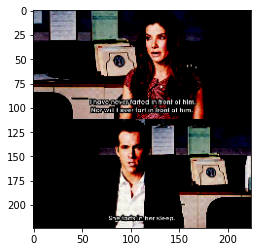

In [45]:
plt.imshow(preprocessed_test_image);

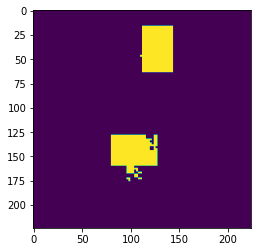

In [46]:
plt.imshow(pred_mask)

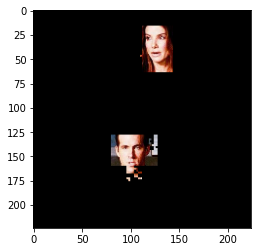

In [47]:
masked_image = image
masked_image[:,:,0] = pred_mask*image[:,:,0]
masked_image[:,:,1] = pred_mask*image[:,:,1]
masked_image[:,:,2] = pred_mask*image[:,:,2]

out_image = masked_image

plt.imshow(out_image)

We can see that the prediction mask encompasses the face in the prediction image

So, we can see that we can see that we created a face detection model using the training data and as well as predicted the mask on the prediction image and results seemed very decent by following the steps mentioned in the project.

# Face recognition
Task is to recognize a faces

### Dataset
**Aligned Face Dataset from Pinterest**

This dataset contains 10.770 images for 100 people. All images are taken from 'Pinterest' and      aligned using dlib library.

#### Mount Google drive if you are using google colab
- We recommend using Google Colab as you can face memory issues and longer runtimes while running on local

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#### Change current working directory to project folder. [ Score: 2 points ]

In [2]:
# Switching to appopriate folder to extract files

import os
os.chdir('drive/My Drive/Colab Data/CV_Project_2/Part_Two')

In [3]:
# Displaying the files in the folder

!ls

'Part 2- Test Image - Benedict Cumberbatch9.jpg'
'Part 2 - Test Image - Dwayne Johnson4.jpg'
'Part 3 - Aligned Face Dataset from Pinterest.zip'
'Part 3 - vgg_face_weights.h5'


#### Extract the zip file [ Score: 2 points ]
- Extract Aligned Face Dataset from Pinterest.zip

In [4]:
from zipfile import ZipFile
with ZipFile('Part 3 - Aligned Face Dataset from Pinterest.zip', 'r') as z:
  z.extractall()

### Function to load images
- Define a function to load the images from the extracted folder and map each image with person id 


In [5]:
import numpy as np
import os

class IdentityMetadata():
    def __init__(self, base, name, file):
        # print(base, name, file)
        # dataset base directory
        self.base = base
        # identity name
        self.name = name
        # image file name
        self.file = file

    def __repr__(self):
        return self.image_path()

    def image_path(self):
        return os.path.join(self.base, self.name, self.file) 
    
def load_metadata(path):
    metadata = []
    for i in os.listdir(path):
        for f in os.listdir(os.path.join(path, i)):
            # Check file extension. Allow only jpg/jpeg' files.
            ext = os.path.splitext(f)[1]
            if ext == '.jpg' or ext == '.jpeg':
                metadata.append(IdentityMetadata(path, i, f))
    return np.array(metadata)

# metadata = load_metadata('images')
metadata = load_metadata('PINS')

### Define function to load image
- Define a function to load image from the metadata

In [6]:
import cv2
def load_image(path):
    img = cv2.imread(path, 1)
    # OpenCV loads images with color channels
    # in BGR order. So we need to reverse them
    return img[...,::-1]

#### Load a sample image [ Score: 2 points ]
- Load one image using the function "load_image"

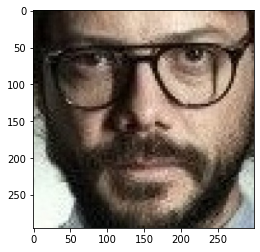

In [7]:
import matplotlib.pyplot as plt
%matplotlib inline
sample_image = load_image(metadata[100].image_path())
plt.imshow(sample_image)

### VGG Face model
- Here we are giving you the predefined model for VGG face

In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import ZeroPadding2D, Convolution2D, MaxPooling2D, Dropout, Flatten, Activation

def vgg_face():	
    model = Sequential()
    model.add(ZeroPadding2D((1,1),input_shape=(224,224, 3)))
    model.add(Convolution2D(64, (3, 3), activation='relu'))
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(64, (3, 3), activation='relu'))
    model.add(MaxPooling2D((2,2), strides=(2,2)))
    
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(128, (3, 3), activation='relu'))
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(128, (3, 3), activation='relu'))
    model.add(MaxPooling2D((2,2), strides=(2,2)))
    
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(256, (3, 3), activation='relu'))
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(256, (3, 3), activation='relu'))
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(256, (3, 3), activation='relu'))
    model.add(MaxPooling2D((2,2), strides=(2,2)))
    
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(512, (3, 3), activation='relu'))
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(512, (3, 3), activation='relu'))
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(512, (3, 3), activation='relu'))
    model.add(MaxPooling2D((2,2), strides=(2,2)))
    
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(512, (3, 3), activation='relu'))
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(512, (3, 3), activation='relu'))
    model.add(ZeroPadding2D((1,1)))
    model.add(Convolution2D(512, (3, 3), activation='relu'))
    model.add(MaxPooling2D((2,2), strides=(2,2)))
    
    model.add(Convolution2D(4096, (7, 7), activation='relu'))
    model.add(Dropout(0.5))
    model.add(Convolution2D(4096, (1, 1), activation='relu'))
    model.add(Dropout(0.5))
    model.add(Convolution2D(2622, (1, 1)))
    model.add(Flatten())
    model.add(Activation('softmax'))
    return model

#### Load the model
- Load the model defined above
- Then load the given weight file named "vgg_face_weights.h5"

In [9]:
model = vgg_face()
model.load_weights('Part 3 - vgg_face_weights.h5')

### Get vgg_face_descriptor

In [10]:
from tensorflow.keras.models import Model
vgg_face_descriptor = Model(inputs=model.layers[0].input, outputs=model.layers[-2].output)

### Generate embeddings for each image in the dataset
- Given below is an example to load the first image in the metadata and get its embedding vector from the pre-trained model. 

In [11]:
# Get embedding vector for first image in the metadata using the pre-trained model

img_path = metadata[0].image_path()
img = load_image(img_path)

# Normalising pixel values from [0-255] to [0-1]: scale RGB values to interval [0,1]
img = (img / 255.).astype(np.float32)

img = cv2.resize(img, dsize = (224,224))
print(img.shape)

# Obtain embedding vector for an image
# Get the embedding vector for the above image using vgg_face_descriptor model and print the shape 

embedding_vector = vgg_face_descriptor.predict(np.expand_dims(img, axis=0))[0]
print(embedding_vector.shape)

(224, 224, 3)
(2622,)


#### Generate embeddings for all images  [ Score: 3 points ]
- Write code to iterate through metadata and create embeddings for each image using `vgg_face_descriptor.predict()` and store in a list with name `embeddings`

- If there is any error in reading any image in the dataset, fill the emebdding vector of that image with 2622-zeroes as the final embedding from the model is of length 2622.

In [12]:
from tqdm import tqdm

embeddings = np.zeros((metadata.shape[0], 2622))

for i, m in tqdm(enumerate(metadata)):
    
    img_path = metadata[i].image_path()
    img = load_image(img_path)
    img = (img / 255.).astype(np.float32)
    img = cv2.resize(img, dsize = (224,224))
    
    embedding_vector = vgg_face_descriptor.predict(np.expand_dims(img, axis=0))[0]
    embeddings[i]= embedding_vector

10770it [13:15, 13.55it/s]


### Function to calculate distance between given 2 pairs of images.

- Consider distance metric as "Squared L2 distance"
- Squared l2 distance between 2 points (x1, y1) and (x2, y2) = (x1-x2)^2 + (y1-y2)^2

In [13]:
def distance(emb1, emb2):
    return np.sum(np.square(emb1 - emb2))

#### Plot images and get distance between the pairs given below
- 2, 3 and 2, 180
- 30, 31 and 30, 100
- 70, 72 and 70, 115

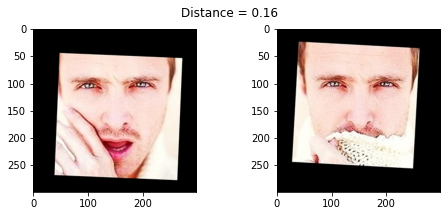

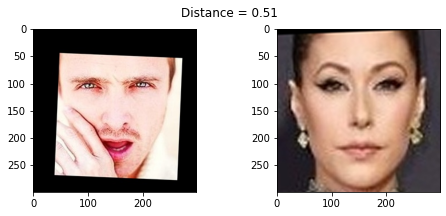

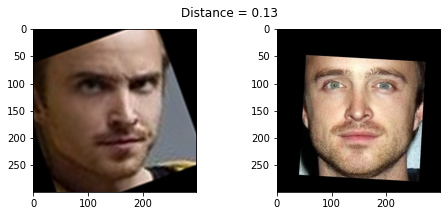

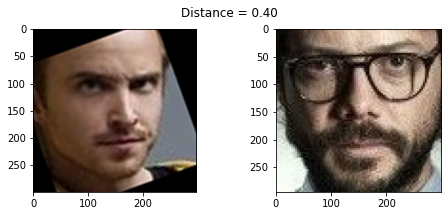

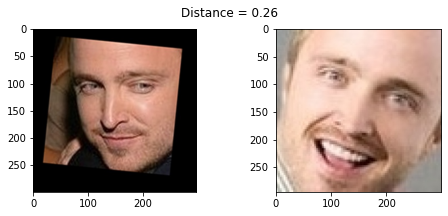

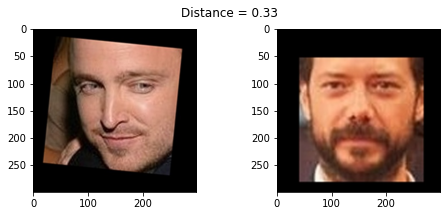

In [14]:
import matplotlib.pyplot as plt

def show_pair(idx1, idx2):
    plt.figure(figsize=(8,3))
    plt.suptitle(f'Distance = {distance(embeddings[idx1], embeddings[idx2]):.2f}')
    plt.subplot(121)
    plt.imshow(load_image(metadata[idx1].image_path()))
    plt.subplot(122)
    plt.imshow(load_image(metadata[idx2].image_path()));    

show_pair(2, 3)
show_pair(2, 180)

show_pair(30, 31)
show_pair(30, 100)

show_pair(70, 72)
show_pair(70, 115)


#### Create train and test sets [ Score: 2 points ]
- Create X_train, X_test and y_train, y_test
- Use train_idx to seperate out training features and labels
- Use test_idx to seperate out testing features and labels

In [15]:
train_idx = np.arange(metadata.shape[0]) % 9 != 0     #every 9th example goes in test data and rest go in train data
test_idx = np.arange(metadata.shape[0]) % 9 == 0

# one half as train examples of 10 identities
X_train = embeddings[train_idx]
# another half as test examples of 10 identities

X_test = embeddings[test_idx]

targets = np.array([m.name for m in metadata])
#train labels
y_train = targets[train_idx]
#test labels
y_test = targets[test_idx]

#### Encode the Labels  [ Score: 2 points ]
- Encode the targets
- Use LabelEncoder

In [16]:
from sklearn.preprocessing import LabelEncoder

enc = LabelEncoder()
enc.fit(targets)

y = enc.transform(targets)
y_train = y[train_idx]
y_test = y[test_idx]

#### Standardize the feature values [ Score: 2 points ]
- Scale the features using StandardScaler

In [17]:
# Standarize features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

#### Reduce dimensions using PCA (3 marks)
- Reduce feature dimensions using Principal Component Analysis
- Set the parameter n_components=128

In [18]:
from sklearn.decomposition import PCA

pca = PCA(128) 
  
X_train = pca.fit_transform(X_train_scaled) 
X_test = pca.transform(X_test_scaled)
 
print(pca.explained_variance_ratio_)

[0.13588907 0.05397996 0.0399038  0.03685076 0.0340078  0.03130051
 0.0259161  0.02335011 0.0210263  0.01942921 0.01818738 0.01701085
 0.01657934 0.01562091 0.01414857 0.01363428 0.01303946 0.01227737
 0.01155234 0.01134523 0.01092548 0.01055393 0.00961389 0.00936725
 0.00914728 0.00883087 0.00833982 0.0076841  0.0076045  0.00736519
 0.00699927 0.00664536 0.00633479 0.00620419 0.00572142 0.00535153
 0.00529045 0.0051194  0.00505976 0.00482456 0.00438459 0.00434225
 0.0039447  0.00393708 0.00370292 0.00356456 0.00340717 0.00334461
 0.00328386 0.00319783 0.00313175 0.00307634 0.00290435 0.00282541
 0.00279101 0.00273295 0.00268621 0.00261383 0.00253895 0.00248398
 0.00237262 0.00231873 0.00225091 0.00217072 0.00210901 0.00205765
 0.00200232 0.00194651 0.00187787 0.00184866 0.00182581 0.00179021
 0.00174437 0.00173486 0.00169883 0.00165647 0.00163981 0.00161589
 0.00157054 0.00155135 0.00152513 0.00149544 0.0014694  0.00143468
 0.00140348 0.00137598 0.00136114 0.00134122 0.00131512 0.0012

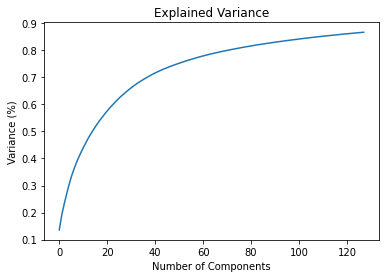

In [19]:
plt.figure()
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Variance (%)') 
plt.title('Explained Variance')
plt.show()

We can see that almost 90 percent variance is handled by 128 principal components which quite decent

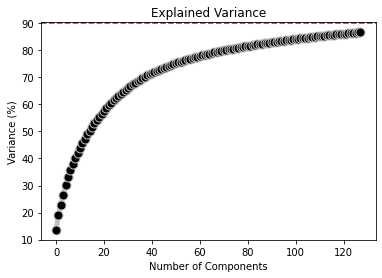

In [20]:
# Plotting the Cumulative Summation of the Explained Variance

plt.figure()
plt.plot(np.cumsum(pca.explained_variance_ratio_) * 100,marker = 'o',color = 'silver',markerfacecolor='black', markersize=9,linewidth=5)
plt.xlabel('Number of Components')
plt.ylabel('Variance (%)')
plt.title('Explained Variance')

# We want to preserve almost 90% of the variance so plotting a horizontal line at 90% variance

plt.axhline(y=90, color='r', linestyle='--')
plt.show()

#### Build a Classifier (3 marks)
- Use SVM Classifier to predict the person in the given image
- Fit the classifier and print the score

In [21]:
from sklearn.svm import SVC

# Trial and error method used for hyperparameter tuning
svc = SVC(C = 2.0, kernel = 'rbf', gamma = 0.0003)
svc.fit(X_train, y_train)
svc_pred = svc.predict(X_test)

In [22]:
from sklearn.metrics import accuracy_score

print('Accuracy Score of SVC Model- ', accuracy_score(y_test, svc_pred))

Accuracy Score of SVC Model-  0.9615705931495405


We can see that accuracy of the model is pretty good

In [23]:
from sklearn.metrics import classification_report

import pandas as pd 
pd.DataFrame(classification_report(y_test, svc_pred,output_dict=True)).T

,precision,recall,f1-score,support
0,1.000000,1.000000,1.000000,10.000000
1,1.000000,1.000000,1.000000,10.000000
2,1.000000,1.000000,1.000000,13.000000
3,1.000000,0.923077,0.960000,13.000000
4,1.000000,1.000000,1.000000,7.000000
...,...,...,...,...
98,1.000000,0.923077,0.960000,13.000000
99,0.923077,1.000000,0.960000,12.000000
accuracy,0.961571,0.961571,0.961571,0.961571
macro avg,0.966380,0.959572,0.961372,1197.000000


Here, we can see that class accuracy is pretty good as well

#### Test results (2 marks)
- Take 10th image from test set and plot the image
- Report to which person(folder name in dataset) the image belongs to

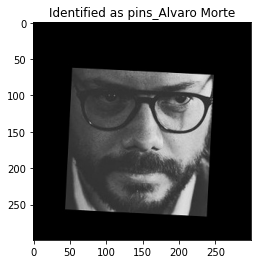

In [24]:
import warnings
# Suppress LabelEncoder warning
warnings.filterwarnings('ignore')

example_idx = 10

example_image = load_image(metadata[test_idx][example_idx].image_path())
example_prediction = svc.predict([X_test[example_idx]])
example_identity = enc.inverse_transform(example_prediction)[0]

plt.imshow(example_image)
plt.title(f'Identified as {example_identity}');

Hence, we can see that the image has been predicted correctly

### <center><b>+ Test : Import the the test image. Display the image. Use the SVM trained model to predict the face</b></center>

Please note that this part is not in questions ipynb file but it was asked in the PDF file holding the project details

In [25]:
# Importing the first image and loading it accordingly

test_img_1 = 'Part 2- Test Image - Benedict Cumberbatch9.jpg'
img1 = load_image(test_img_1)

In [26]:
# Normalising pixel values from [0-255] to [0-1]: scale RGB values to interval [0,1]

img1 = (img1 / 255.).astype(np.float32)
img1 = cv2.resize(img1,(224,224), interpolation = cv2.INTER_CUBIC)
print(img1.shape)

(224, 224, 3)


In [27]:
# Obtaining embedding vector for an image
# Get the embedding vector for the above image using vgg_face_descriptor model and printing the shape 

embedding_vector_1 = vgg_face_descriptor.predict(np.expand_dims(img1, axis=0))[0]
print(embedding_vector_1.shape)

(2622,)


In [28]:
# Reshaping the vector

embedding_vector_1 = embedding_vector_1.reshape(1,-1)

In [29]:
# Scaling the vector

X_1 = scaler.transform(embedding_vector_1)

In [30]:
# Applying PCA on the given image to extract appropriate components

X_1_pca = pca.transform(X_1)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


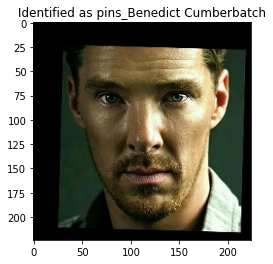

In [31]:
# Predicting the image identity for the given image

example_image_1 = img1
example_prediction_1 = svc.predict(X_1_pca)
example_identity_1 = enc.inverse_transform([example_prediction_1])[0]

plt.imshow(example_image_1)
plt.title(f'Identified as {example_identity_1}');

Hence, we can see that the image's identity has been predicted correctly

In [32]:
# Importing the second image and loading it accordingly

test_img_2 = 'Part 2 - Test Image - Dwayne Johnson4.jpg'
img2 = load_image(test_img_2)

In [33]:
# Normalising pixel values from [0-255] to [0-1]: scale RGB values to interval [0,1]

img2 = (img2 / 255.).astype(np.float32)
img2 = cv2.resize(img2,(224,224), interpolation = cv2.INTER_CUBIC)
print(img2.shape)

(224, 224, 3)


In [34]:
# Obtaining embedding vector for an image
# Get the embedding vector for the above image using vgg_face_descriptor model and printing the shape 

embedding_vector_2 = vgg_face_descriptor.predict(np.expand_dims(img2, axis=0))[0]
print(embedding_vector_2.shape)

(2622,)


In [35]:
# Reshaping the vector

embedding_vector_2 = embedding_vector_2.reshape(1,-1)

In [36]:
# Scaling the vector

X_2 = scaler.transform(embedding_vector_2)

In [37]:
# Applying PCA on the given image to extract appropriate components

X_2_pca = pca.transform(X_2)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


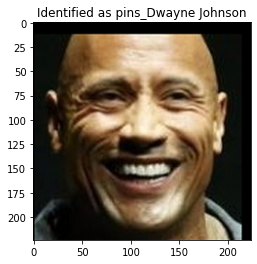

In [38]:
# Predicting the image identity for the given image

example_image_2 = img2
example_prediction_2 = svc.predict(X_2_pca)
example_identity_2 = enc.inverse_transform([example_prediction_2])[0]

plt.imshow(example_image_2)
plt.title(f'Identified as {example_identity_2}');

So, at end we can conclude that the model is performing decently and predictions are good